Gallstone Prediction

Gallstones are hardened deposits that can form in the gallbladder, potentially leading to significant health issues. Early prediction and detection using machine learning can aid in timely medical intervention. This project aims to build a classification model that predicts whether a patient is likely to develop gallstones based on medical and lifestyle features.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, mean_squared_error

Data Preprocessing

We begin by loading the dataset and performing initial data exploration:
- **Shape and Preview:** We inspect the first and last few rows to understand the data structure.
- **Summary Statistics:** Descriptive statistics help us understand the distribution and range of each feature.
- **Data Types and Missing Values:** We check for missing values and ensure all features are of appropriate data types.


In [3]:
gl = pd.read_csv('dataset-uci.csv')
gl.head()
gl.tail()

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
314,1,49,0,0,0,0,0,0,178,88.8,...,55.0,81.0,28.0,50.0,90.0,0.98,94.50,6.2,16.5,8.3
315,1,31,1,0,0,0,0,0,157,53.4,...,58.0,64.0,24.0,16.0,38.0,0.50,128.50,0.0,12.5,24.0
316,1,58,0,0,0,0,0,0,172,96.6,...,45.0,168.0,21.0,27.0,94.0,1.04,83.23,0.0,15.4,15.7
317,1,37,1,0,0,0,0,0,177,88.4,...,33.0,253.0,40.0,22.0,115.0,1.01,98.23,0.4,16.0,33.3
318,1,60,1,0,0,0,0,0,154,63.5,...,273.0,19.0,25.0,73.0,73.0,0.85,73.00,0.0,13.6,29.0


In [35]:
#dataset description
gl.describe().T


,count,mean,std,min,25%,50%,75%,max
Gallstone Status,319.0,0.495298,0.500763,0.00,0.000,0.000000,1.000,1.00
Age,319.0,48.068966,12.114558,20.00,38.500,49.000000,56.000,96.00
Gender,319.0,0.492163,0.500724,0.00,0.000,0.000000,1.000,1.00
Comorbidity,319.0,0.335423,0.517340,0.00,0.000,0.000000,1.000,3.00
Coronary Artery Disease (CAD),319.0,0.037618,0.190568,0.00,0.000,0.000000,0.000,1.00
Hypothyroidism,319.0,0.028213,0.165841,0.00,0.000,0.000000,0.000,1.00
Hyperlipidemia,319.0,0.025078,0.156609,0.00,0.000,0.000000,0.000,1.00
Diabetes Mellitus (DM),319.0,0.134796,0.342042,0.00,0.000,0.000000,0.000,1.00
Height,319.0,167.156740,10.053030,145.00,159.500,168.000000,175.000,191.00
Weight,319.0,80.564890,15.709069,42.90,69.600,78.800000,91.250,143.50


In [5]:
gl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

In [6]:
#check for missing values
gl.isnull().sum()

Gallstone Status                                  0
Age                                               0
Gender                                            0
Comorbidity                                       0
Coronary Artery Disease (CAD)                     0
Hypothyroidism                                    0
Hyperlipidemia                                    0
Diabetes Mellitus (DM)                            0
Height                                            0
Weight                                            0
Body Mass Index (BMI)                             0
Total Body Water (TBW)                            0
Extracellular Water (ECW)                         0
Intracellular Water (ICW)                         0
Extracellular Fluid/Total Body Water (ECF/TBW)    0
Total Body Fat Ratio (TBFR) (%)                   0
Lean Mass (LM) (%)                                0
Body Protein Content (Protein) (%)                0
Visceral Fat Rating (VFR)                         0
Bone Mass (B

Exploratory data analysis

EDA helps uncover patterns, relationships, and anomalies in the data:
- **Target Variable Distribution:** Visualized to check class balance.
- **Feature Distributions:** Histograms and boxplots for key features (e.g., Age, BMI, Cholesterol, Glucose) reveal their spread and potential outliers.
- **Correlation Analysis:** Heatmaps show relationships between features and with the target variable.
- **Feature-Target Relationships:** Boxplots compare feature distributions across gallstone status classes.


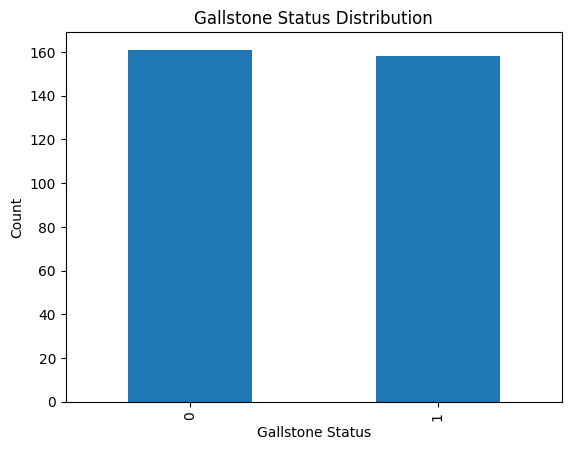

In [16]:
#target variable distribution
y.value_counts().plot(kind='bar')
plt.title('Gallstone Status Distribution')
plt.xlabel('Gallstone Status')
plt.ylabel('Count')
plt.show()

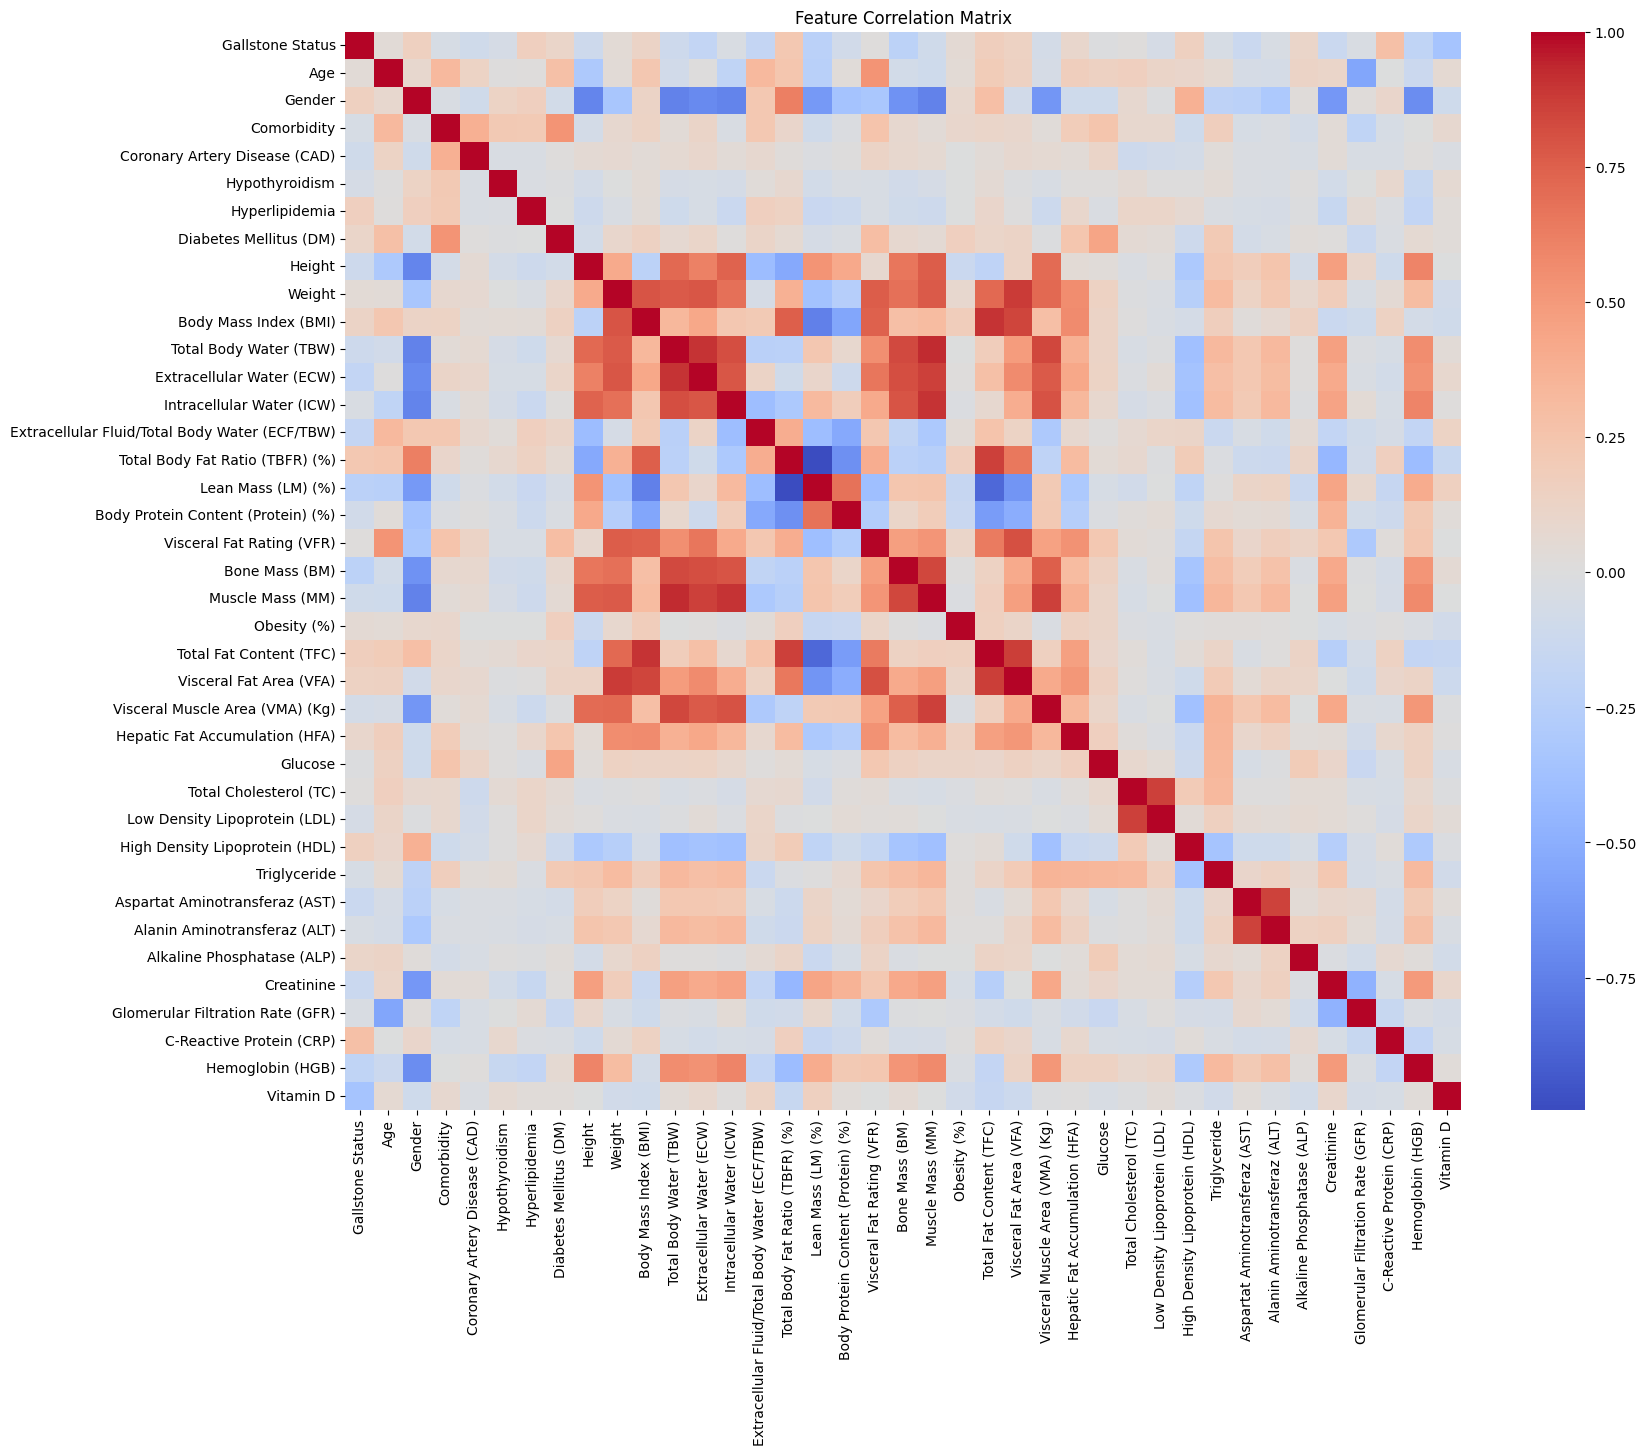

In [27]:
# Plot the correlation matrix as a heatmap
import seaborn as sns
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

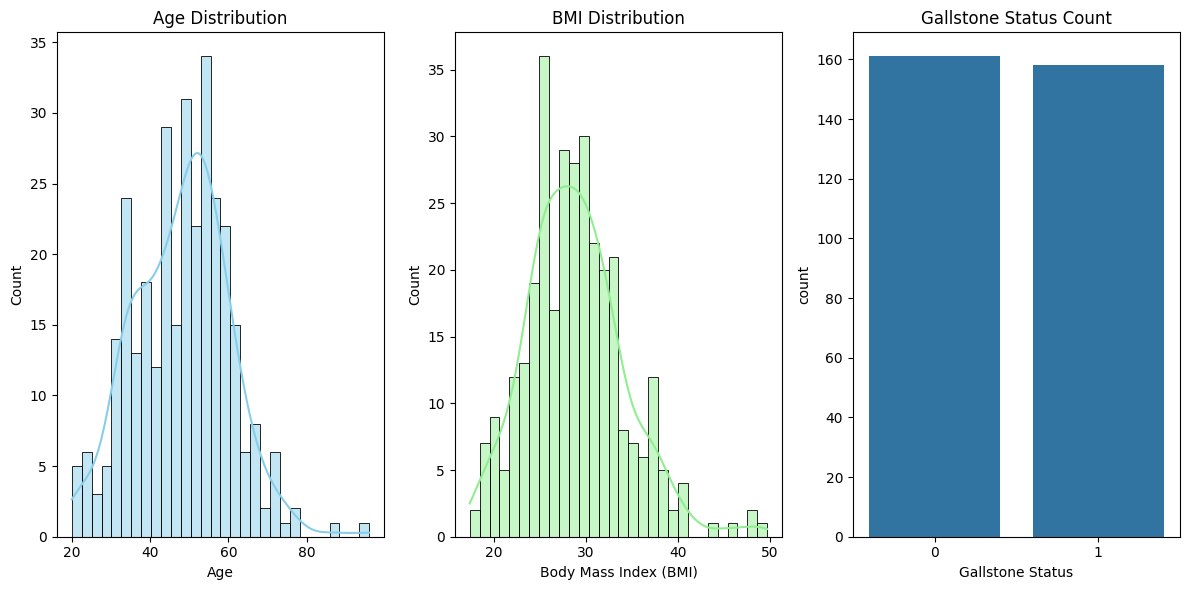

In [22]:
#visualize distribution of age, bmi, and gallstone status
import seaborn as sns

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.histplot(gl['Age'], kde=True, bins=30, color='skyblue')
plt.title('Age Distribution')
plt.subplot(1, 3, 2)
sns.histplot(gl['Body Mass Index (BMI)'], kde=True, bins=30, color='lightgreen')
plt.title('BMI Distribution')
plt.subplot(1, 3, 3)
sns.countplot(x='Gallstone Status', data=gl)
plt.title('Gallstone Status Count')
plt.tight_layout()
plt.show()


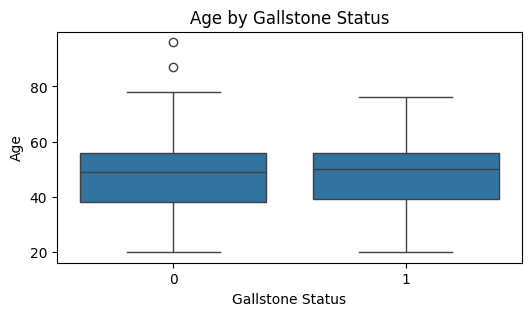

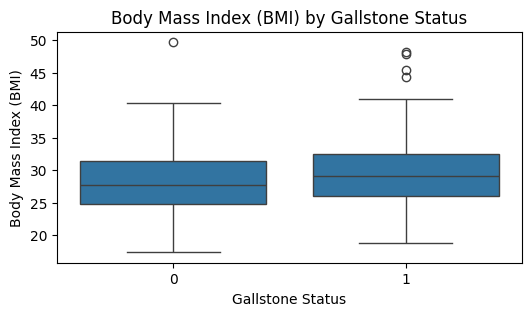

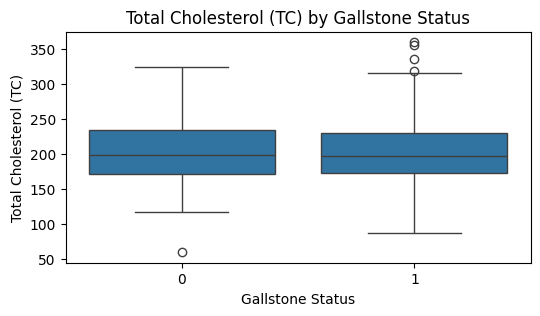

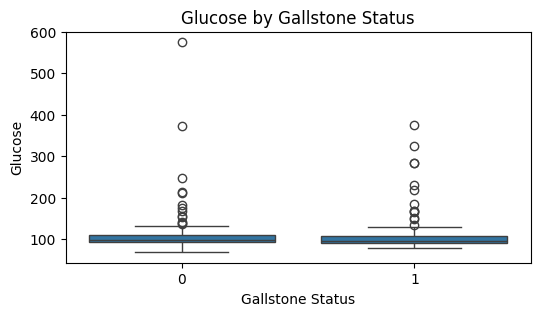

In [21]:
# Compare feature distributions by target
for col in ['Age', 'Body Mass Index (BMI)', 'Total Cholesterol (TC)', 'Glucose']:
    if col in gl.columns:
        plt.figure(figsize=(6, 3))
        sns.boxplot(x='Gallstone Status', y=col, data=gl)
        plt.title(f'{col} by Gallstone Status')
        plt.show()

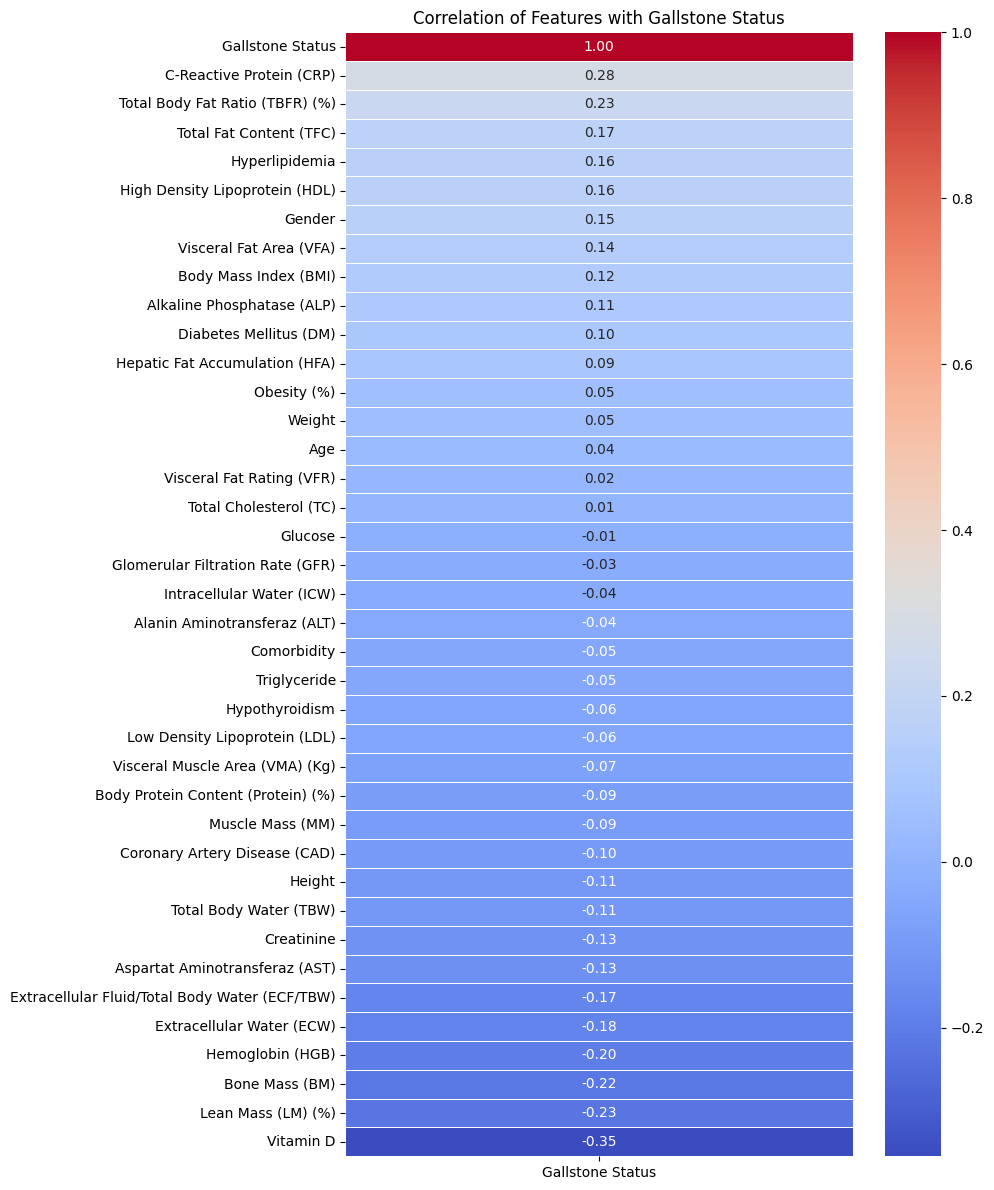

In [20]:
# Compute correlation matrix
corr_matrix = gl.corr(numeric_only=True)

# Heatmap of correlations with target
plt.figure(figsize=(10, 12))
sns.heatmap(corr_matrix[['Gallstone Status']].sort_values(by='Gallstone Status', ascending=False),
            annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation of Features with Gallstone Status')
plt.tight_layout()
plt.show()

Feature Scaling and Data Splitting

- **Feature Scaling:** StandardScaler is used to normalize features, ensuring all variables contribute equally to model training.
- **Train-Test Split:** The dataset is split into training and testing sets (80/20 split) to evaluate model generalization.


In [13]:
from sklearn.preprocessing import StandardScaler
X = gl.drop(columns=['Gallstone Status'])
y = gl['Gallstone Status']



In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
#split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

 Model Training and Evaluation

### Logistic Regression

- **Training:** A logistic regression model is trained on the scaled features.
- **Evaluation:** Model performance is assessed using accuracy, classification report, and confusion matrix.
- **Feature Importance:** The absolute values of the model coefficients are plotted to interpret which features most influence predictions.


In [36]:
from sklearn.metrics import classification_report, confusion_matrix

#logistic regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
# Make predictions
y_pred_log = log_reg.predict(X_test)
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_log)
report = classification_report(y_test, y_pred_log)
conf_matrix = confusion_matrix(y_test, y_pred_log)

# Output results
print("Accuracy:", accuracy)
print("\nClassification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.78125

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.88      0.81        33
           1       0.84      0.68      0.75        31

    accuracy                           0.78        64
   macro avg       0.79      0.78      0.78        64
weighted avg       0.79      0.78      0.78        64

Confusion Matrix:
 [[29  4]
 [10 21]]


### Random Forest Classifier

- **Training:** A random forest classifier is trained as a robust, non-linear alternative.
- **Evaluation:** Accuracy, classification report, and confusion matrix are used to assess performance.


In [37]:
#random forest classifier before hyyperparameter tuning
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
# Make predictions
y_pred_rf = rf_clf.predict(X_test)
# Evaluate the model
accuracy_score_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Classifier Accuracy: {accuracy_score_rf:.2f}")
print("Random Forest Classifier Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest Classifier Confusion Matrix:")
confusion_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print(confusion_matrix_rf)


Random Forest Classifier Accuracy: 0.80
Random Forest Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        33
           1       0.78      0.81      0.79        31

    accuracy                           0.80        64
   macro avg       0.80      0.80      0.80        64
weighted avg       0.80      0.80      0.80        64

Random Forest Classifier Confusion Matrix:
[[26  7]
 [ 6 25]]


## Hyperparameter Tuning

### Logistic Regression

To optimize the logistic regression model, we use `GridSearchCV` to search over a range of regularization strengths (`C`) and penalty types (`l1`, `l2`) with the `liblinear` solver. The best parameters are selected based on cross-validated accuracy, and the optimized model is evaluated on the test set.


Best parameters for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Logistic Regression Accuracy: 78.12
Best Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.85      0.80        33
           1       0.81      0.71      0.76        31

    accuracy                           0.78        64
   macro avg       0.79      0.78      0.78        64
weighted avg       0.78      0.78      0.78        64

Best Logistic Regression Confusion Matrix:
[[28  5]
 [ 9 22]]


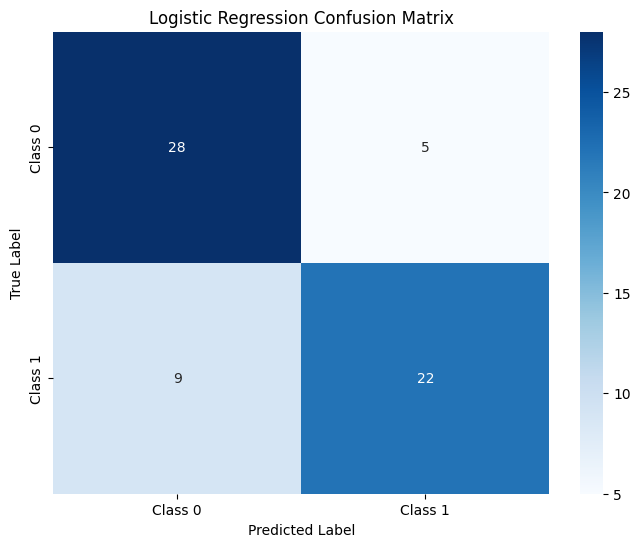

In [49]:
#hyperparameter tuning for logistic regression
from sklearn.model_selection import GridSearchCV
param_grid = [
    {
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear'],
        'C': [0.01, 0.1, 1, 10, 100],
    },
]

grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best parameters for Logistic Regression:", grid_search.best_params_)
# Train the best model
best_log_reg = grid_search.best_estimator_
# Make predictions with the best model
y_pred_best_log = best_log_reg.predict(X_test)
# Evaluate the best model
accuracy_best_log = (accuracy_score(y_test, y_pred_best_log)*100)
print(f"Best Logistic Regression Accuracy: {accuracy_best_log:.2f}")

#make predictions with the best model
print("Best Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_best_log))
print("Best Logistic Regression Confusion Matrix:")
confusion_matrix_best_log = confusion_matrix(y_test, y_pred_best_log)
print(confusion_matrix_best_log)

# Plot confusion matrix for logistic regression
def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Logistic Regression Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

plot_confusion_matrix(confusion_matrix_best_log, classes=['Class 0', 'Class 1'])

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters from RandomizedSearchCV: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 50}
Best Random Forest Model Accuracy: 85.94%
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.87        33
           1       0.87      0.84      0.85        31

    accuracy                           0.86        64
   macro avg       0.86      0.86      0.86        64
weighted avg       0.86      0.86      0.86        64

Confusion Matrix:
 [[29  4]
 [ 5 26]]


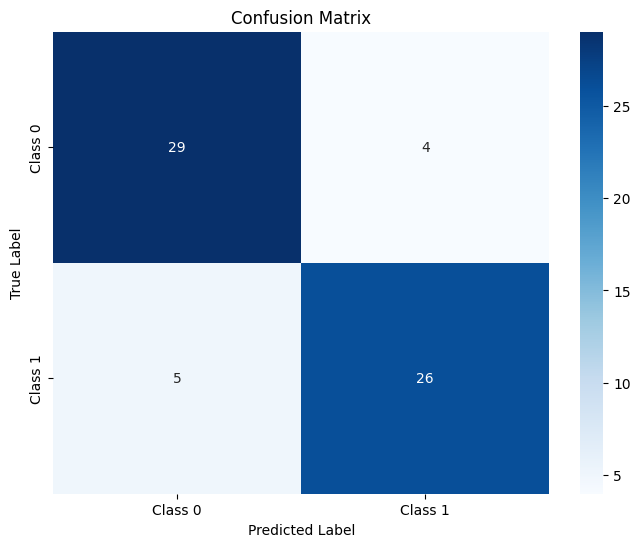

In [42]:
from sklearn.model_selection import RandomizedSearchCV

# Use RandomizedSearchCV for hyperparameter tuning of Random Forest

# Define the parameter distribution for Random Forest
param_dist_rf = {
    'n_estimators': [50, 100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6]
}

# Initialize RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    estimator=rf_clf,
    param_distributions=param_dist_rf,
    n_iter=20,                # Number of parameter settings sampled
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit RandomizedSearchCV to the training data
random_search_rf.fit(X_train, y_train)

# Output the best parameters and best score
print("Best Parameters from RandomizedSearchCV:", random_search_rf.best_params_)

# Make predictions with the best Random Forest model
best_rf_clf = random_search_rf.best_estimator_
y_pred_best_rf = best_rf_clf.predict(X_test)
# Evaluate the best Random Forest model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Best Random Forest Model Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred_best_rf) * 100))
print("Classification Report:\n", classification_report(y_test, y_pred_best_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best_rf))


#plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_best_rf)
plot_confusion_matrix(cm, classes=['Class 0', 'Class 1'])  # Adjust class names as needed

Feature  Selection

In [ ]:
#Feauture selction for top 7features
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k=7)
X_new = selector.fit_transform(X_train, y_train)
# Get the selected feature indices
selected_indices = selector.get_support(indices=True)
# Get the names of the selected features
selected_features = X.columns[selected_indices]
print("Selected Features:", selected_features.tolist()) 


Selected Features: ['Extracellular Water (ECW)', 'Extracellular Fluid/Total Body Water (ECF/TBW)', 'Lean Mass (LM) (%)', 'Bone Mass (BM)', 'C-Reactive Protein (CRP)', 'Hemoglobin (HGB)', 'Vitamin D']


Best Logistic Regression with Selected Features Accuracy: 82.81
Best Logistic Regression with Selected Features Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.91      0.85        33
           1       0.88      0.74      0.81        31

    accuracy                           0.83        64
   macro avg       0.84      0.83      0.83        64
weighted avg       0.84      0.83      0.83        64



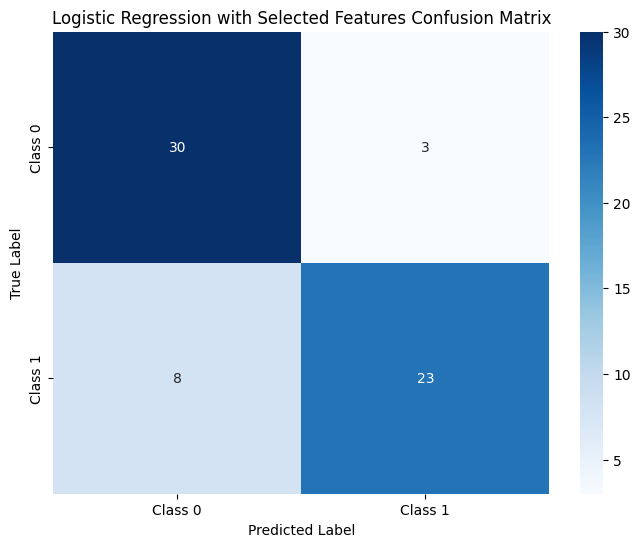

In [66]:

# Train a new logistic regression model with top 7  selected features
best_log_reg.fit(X_new, y_train)
# Make predictions with the new model
X_test_new = selector.transform(X_test)
y_pred_best_log_new = best_log_reg.predict(X_test_new)
# Evaluate the new model
accuracy_best_log_new = (accuracy_score(y_test, y_pred_best_log_new)*100)
print(f"Best Logistic Regression with Selected Features Accuracy: {accuracy_best_log_new:.2f}")
print("Best Logistic Regression with Selected Features Classification Report:")
print(classification_report(y_test, y_pred_best_log_new))
# Plot confusion matrix for logistic regression with selected features
def plot_confusion_matrix_new(cm, classes):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Logistic Regression with Selected Features Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
plot_confusion_matrix_new(confusion_matrix_best_log_new, classes=['Class 0', 'Class 1'])


Random Forest Classifier with Selected Features Accuracy: 82.81
Random Forest Classifier with Selected Features Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83        33
           1       0.81      0.84      0.83        31

    accuracy                           0.83        64
   macro avg       0.83      0.83      0.83        64
weighted avg       0.83      0.83      0.83        64



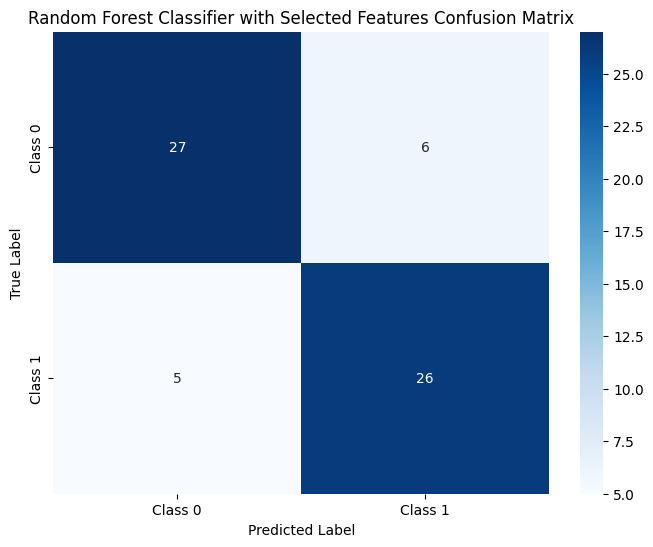

In [65]:

#Train a Random Forest Classifier with selected features
rf_clf_new = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf_new.fit(X_new, y_train)
# Make predictions with the new Random Forest model
y_pred_rf_new = rf_clf_new.predict(X_test_new)
# Evaluate the new Random Forest model
y_pred_rf_new = rf_clf_new.predict(X_test_new)
accuracy_score_rf_new = (accuracy_score(y_test, y_pred_rf_new)*100)
print(f"Random Forest Classifier with Selected Features Accuracy: {accuracy_score_rf_new:.2f}")
print("Random Forest Classifier with Selected Features Classification Report:")
print(classification_report(y_test, y_pred_rf_new))
# Plot confusion matrix for Random Forest with selected features
def plot_confusion_matrix_rf_new(cm, classes):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Random Forest Classifier with Selected Features Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
plot_confusion_matrix_rf_new(confusion_matrix_rf_new, classes=['Class 0', 'Class 1'])

In [67]:
#feature selection for top 5 feautures
selector_5 = SelectKBest(score_func=f_classif, k=5)
X_new_5 = selector_5.fit_transform(X_train, y_train)
# Get the selected feature indices
selected_indices_5 = selector_5.get_support(indices=True)
# Get the names of the selected features
selected_features_5 = X.columns[selected_indices_5]
print("Selected Features (Top 5):", selected_features_5.tolist())


Selected Features (Top 5): ['Extracellular Water (ECW)', 'Bone Mass (BM)', 'C-Reactive Protein (CRP)', 'Hemoglobin (HGB)', 'Vitamin D']


Best Logistic Regression with Selected Features (Top 5) Accuracy: 76.56
Best Logistic Regression with Selected Features (Top 5) Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.78        33
           1       0.77      0.74      0.75        31

    accuracy                           0.77        64
   macro avg       0.77      0.76      0.77        64
weighted avg       0.77      0.77      0.77        64



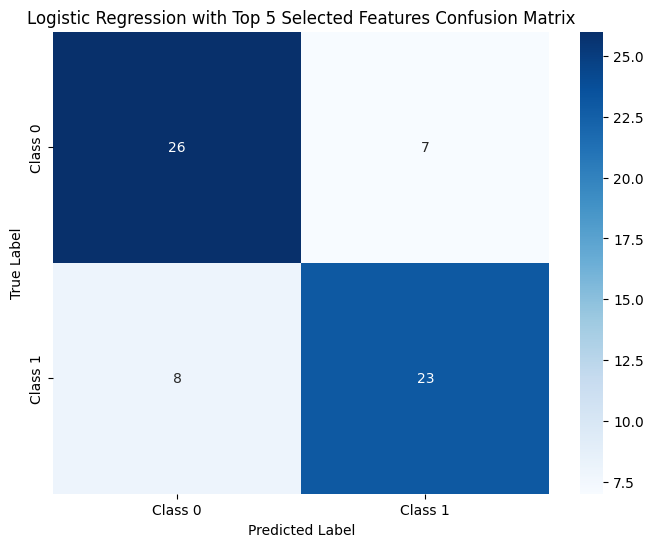

In [69]:
#new Logistic Regression model with top 5 selected features
best_log_reg_5 = LogisticRegression(max_iter=1000)
best_log_reg_5.fit(X_new_5, y_train)
# Make predictions with the new model
X_test_new_5 = selector_5.transform(X_test)
y_pred_best_log_new_5 = best_log_reg_5.predict(X_test_new_5)
# Evaluate the new model
accuracy_best_log_new_5 = (accuracy_score(y_test, y_pred_best_log_new_5)*100)
print(f"Best Logistic Regression with Selected Features (Top 5) Accuracy: {accuracy_best_log_new_5:.2f}")
print("Best Logistic Regression with Selected Features (Top 5) Classification Report:")
print(classification_report(y_test, y_pred_best_log_new_5)) 
# Plot confusion matrix for logistic regression with top 5 selected features
plot_confusion_matrix_new_5 = confusion_matrix(y_test, y_pred_best_log_new_5)
def plot_confusion_matrix_logistic_5(cm, classes):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Logistic Regression with Top 5 Selected Features Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
plot_confusion_matrix_logistic_5(plot_confusion_matrix_new_5, classes=['Class 0', 'Class 1'])


Random Forest Classifier with Selected Features (Top 5) Accuracy: 79.69
Random Forest Classifier with Selected Features (Top 5) Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.73      0.79        33
           1       0.75      0.87      0.81        31

    accuracy                           0.80        64
   macro avg       0.80      0.80      0.80        64
weighted avg       0.81      0.80      0.80        64



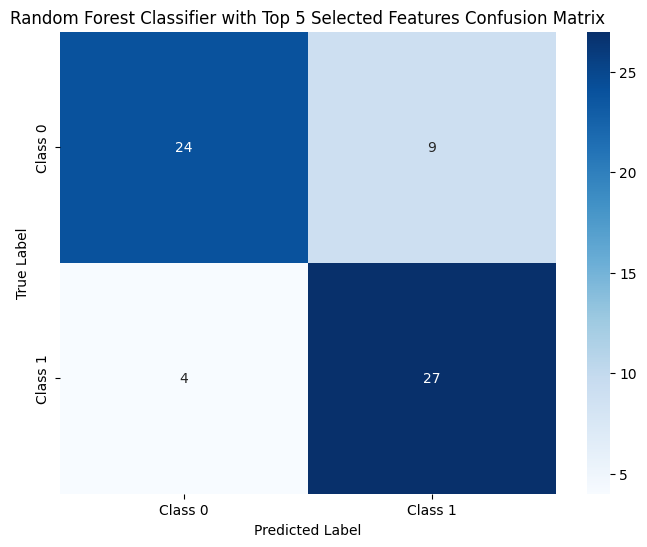

In [78]:
#random forest classifier with top 5 selected features
rf_clf_new_5 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf_new_5.fit(X_new_5, y_train)
# Make predictions with the new Random Forest model
y_pred_rf_new_5 = rf_clf_new_5.predict(X_test_new_5)
# Evaluate the new Random Forest model
accuracy_score_rf_new_5 = (accuracy_score(y_test, y_pred_rf_new_5)*100)
print(f"Random Forest Classifier with Selected Features (Top 5) Accuracy: {accuracy_score_rf_new_5:.2f}")
print("Random Forest Classifier with Selected Features (Top 5) Classification Report:")
print(classification_report(y_test, y_pred_rf_new_5))
# Plot confusion matrix for Random Forest with top 5 selected features
def plot_confusion_matrix_rf_new_5(cm, classes):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Random Forest Classifier with Top 5 Selected Features Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
plot_confusion_matrix_rf_new_5(confusion_matrix(y_test, y_pred_rf_new_5), classes=['Class 0', 'Class 1'])